# Predictive Maintenance: Walk-Forward CV for Turbofan RUL Estimation

## Domain context

Remaining Useful Life (RUL) prediction is what condition-based maintenance runs on, whether in aerospace, manufacturing, or energy. The standard benchmark is NASA's C-MAPSS (Commercial Modular Aero-Propulsion System Simulation) dataset (Saxena *et al.*, 2008): sensor readings from turbofan engines run to failure under varying operating conditions.

Its temporal structure causes a quiet problem for ordinary cross-validation. Each engine is an independent unit that degrades steadily toward failure, and the sensor readings within one engine's life are heavily autocorrelated. Split the rows at random and cycles from the same engine's late degradation end up in both train and test, so the model memorises specific failure trajectories instead of learning the degradation itself.

`WalkForwardSplit` fixes this by anchoring the train/test boundary in time, using cycle as a stand-in for date. Training only ever uses data from before the test window, and `purge_horizon` and `embargo` clear the autocorrelated overlap zone around it.

**Data source:** NASA C-MAPSS FD001 subset — 100 turbofan engines, run-to-failure sensor streams. Downloaded from a stable GitHub mirror of the official NASA Prognostics Center distribution (hankroark/Turbofan-Engine-Degradation).
License: NASA Open Government License.

In [1]:
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

import purgedcv
from purgedcv import WalkForwardSplit, diagnostics

print(f"purged-cross-validation version: {purgedcv.__version__}")

purged-cross-validation version: 0.3.0a0


## Data download and caching

Downloads once, caches in `examples/data/`. The download is about 6 MB (train + test + RUL).
Source: https://github.com/hankroark/Turbofan-Engine-Degradation

In [2]:
DATA_DIR = Path("data") if Path("data").exists() else Path("examples/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

BASE_URL = (
    "https://raw.githubusercontent.com/hankroark/Turbofan-Engine-Degradation/master/CMAPSSData"
)


def fetch(url: str, dest_name: str) -> Path:
    dest = DATA_DIR / dest_name
    if dest.exists():
        print(f"Using cached: {dest}")
        return dest
    print(f"Downloading {url} ...")
    req = urllib.request.Request(
        url, headers={"User-Agent": "purged-cross-validation-examples/0.3.0a0"}
    )
    with urllib.request.urlopen(req, timeout=60) as response, open(dest, "wb") as f:
        f.write(response.read())
    print(f"Cached at {dest}")
    return dest


train_path = fetch(f"{BASE_URL}/train_FD001.txt", "train_FD001.txt")
test_path = fetch(f"{BASE_URL}/test_FD001.txt", "test_FD001.txt")
rul_path = fetch(f"{BASE_URL}/RUL_FD001.txt", "RUL_FD001.txt")

Using cached: data/train_FD001.txt
Using cached: data/test_FD001.txt
Using cached: data/RUL_FD001.txt


## Load and parse NASA C-MAPSS FD001

The files are whitespace-delimited with no header. The 26 columns are `engine_id, cycle, op_setting_1, op_setting_2, op_setting_3, sensor_1 ... sensor_21`.

For the training set, RUL = max(cycle_for_engine) − cycle, since each engine fails at its last cycle. We attach a synthetic calendar date (one cycle = one day from 2018-01-01) so the data works with `WalkForwardSplit`'s timestamp-based API.

In [3]:
COLS = ["engine_id", "cycle", "op_setting_1", "op_setting_2", "op_setting_3"] + [
    f"sensor_{i}" for i in range(1, 22)
]

train_df = pd.read_csv(train_path, sep=r"\s+", header=None, names=COLS)
test_df = pd.read_csv(test_path, sep=r"\s+", header=None, names=COLS)
rul_values = pd.read_csv(rul_path, sep=r"\s+", header=None, names=["rul_at_cutoff"])

# ── Compute RUL for training data ──────────────────────────────────────────
max_cycles = train_df.groupby("engine_id")["cycle"].max().rename("max_cycle")
train_df = train_df.merge(max_cycles, on="engine_id")
train_df["rul"] = train_df["max_cycle"] - train_df["cycle"]
train_df = train_df.drop(columns=["max_cycle"])

# ── Assign synthetic timestamp (1 cycle = 1 day) ───────────────────────────
BASE_DATE = pd.Timestamp("2018-01-01")

# Global ordering: engines are sequential; stagger their start dates
engine_offsets = {eid: i * 400 for i, eid in enumerate(sorted(train_df["engine_id"].unique()))}
train_df["timestamp"] = train_df.apply(
    lambda row: BASE_DATE + pd.Timedelta(days=engine_offsets[row["engine_id"]] + row["cycle"]),
    axis=1,
)
train_df = train_df.sort_values("timestamp").reset_index(drop=True)

print(f"Training set: {train_df.shape[0]:,} rows, {train_df['engine_id'].nunique()} engines")
print(f"Cycle range per engine: min={train_df['cycle'].min()}, max={train_df['cycle'].max()}")
print(f"Date range: {train_df['timestamp'].min().date()} to {train_df['timestamp'].max().date()}")
train_df[["engine_id", "cycle", "rul", "timestamp", "sensor_2", "sensor_4"]].head()

Training set: 20,631 rows, 100 engines
Cycle range per engine: min=1, max=362
Date range: 2018-01-02 to 2126-12-21


,engine_id,cycle,rul,timestamp,sensor_2,sensor_4
0,1,1,191,2018-01-02,641.82,1400.60
1,1,2,190,2018-01-03,642.15,1403.14
2,1,3,189,2018-01-04,642.35,1404.20
3,1,4,188,2018-01-05,642.35,1401.87
4,1,5,187,2018-01-06,642.37,1406.22


## Visualising sensor degradation

The two most diagnostic channels for FD001: sensor_2 (temperature at the LPT outlet), which rises, and sensor_11 (high-pressure-turbine coolant bleed), which falls, plotted against cycle number.

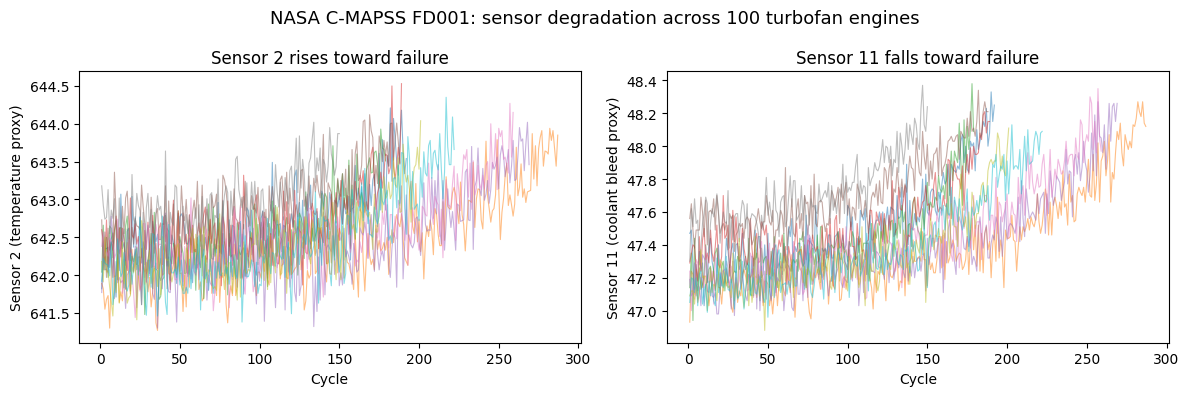

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("NASA C-MAPSS FD001: sensor degradation across 100 turbofan engines", fontsize=13)

sample_engines = train_df["engine_id"].unique()[:10]

for eid in sample_engines:
    sub = train_df[train_df["engine_id"] == eid].sort_values("cycle")
    ax1.plot(sub["cycle"], sub["sensor_2"], alpha=0.5, lw=0.8)
    ax2.plot(sub["cycle"], sub["sensor_11"], alpha=0.5, lw=0.8)

ax1.set_xlabel("Cycle")
ax1.set_ylabel("Sensor 2 (temperature proxy)")
ax1.set_title("Sensor 2 rises toward failure")

ax2.set_xlabel("Cycle")
ax2.set_ylabel("Sensor 11 (coolant bleed proxy)")
ax2.set_title("Sensor 11 falls toward failure")

plt.tight_layout()
plt.show()

## Walk-forward split setup

We run `WalkForwardSplit` with an expanding window, so each fold trains on everything before its test window. That mirrors real deployment, where the model is retrained from time to time as more engine histories pile up.

`purge_horizon="3D"` drops training rows whose label horizon overlaps the test period by 3 cycles, and `embargo="5D"` adds a 5-cycle buffer for autocorrelated residuals.

In [5]:
SENSOR_COLS = [f"sensor_{i}" for i in range(1, 22)]
X = train_df[SENSOR_COLS].values
y = train_df["rul"].values

prediction_times = train_df["timestamp"].reset_index(drop=True)
evaluation_times = prediction_times + pd.Timedelta(days=1)

cv = WalkForwardSplit(
    n_splits=5,
    test_size=500,
    window="expanding",
    prediction_times=prediction_times,
    evaluation_times=evaluation_times,
    purge_horizon="3D",
    embargo="5D",
)

print(f"Number of walk-forward folds: {cv.get_n_splits()}")
print(f"Total training rows: {len(train_df):,}")

Number of walk-forward folds: 5
Total training rows: 20,631


## Training and evaluation per fold

In [6]:
fold_maes = []
fold_train_sizes = []
fold_test_ranges = []

for fold_i, (train_idx, test_idx) in enumerate(cv.split(X)):
    reg = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=0)
    reg.fit(X[train_idx], y[train_idx])
    preds = reg.predict(X[test_idx])
    mae = mean_absolute_error(y[test_idx], preds)
    fold_maes.append(mae)
    fold_train_sizes.append(len(train_idx))

    diagnostics.assert_no_temporal_leakage(
        train_idx,
        test_idx,
        prediction_times,
        evaluation_times,
        purge_horizon="3D",
    )

    test_start = prediction_times.iloc[test_idx].min().date()
    test_end = prediction_times.iloc[test_idx].max().date()
    fold_test_ranges.append(f"{test_start} to {test_end}")
    print(
        f"  Fold {fold_i + 1}: train={len(train_idx):,} rows, "
        f"test={len(test_idx):,} rows, "
        f"MAE={mae:.1f} cycles — no leakage ✓"
    )

print(f"\nMean MAE: {np.mean(fold_maes):.1f} cycles")
print(f"Std  MAE: {np.std(fold_maes):.1f} cycles")

  Fold 1: train=18,128 rows, test=500 rows, MAE=57.6 cycles — no leakage ✓


  Fold 2: train=18,628 rows, test=500 rows, MAE=43.6 cycles — no leakage ✓


  Fold 3: train=19,128 rows, test=500 rows, MAE=44.0 cycles — no leakage ✓


  Fold 4: train=19,628 rows, test=500 rows, MAE=26.8 cycles — no leakage ✓


  Fold 5: train=20,128 rows, test=500 rows, MAE=31.1 cycles — no leakage ✓

Mean MAE: 40.6 cycles
Std  MAE: 10.9 cycles


## MAE evolution across folds

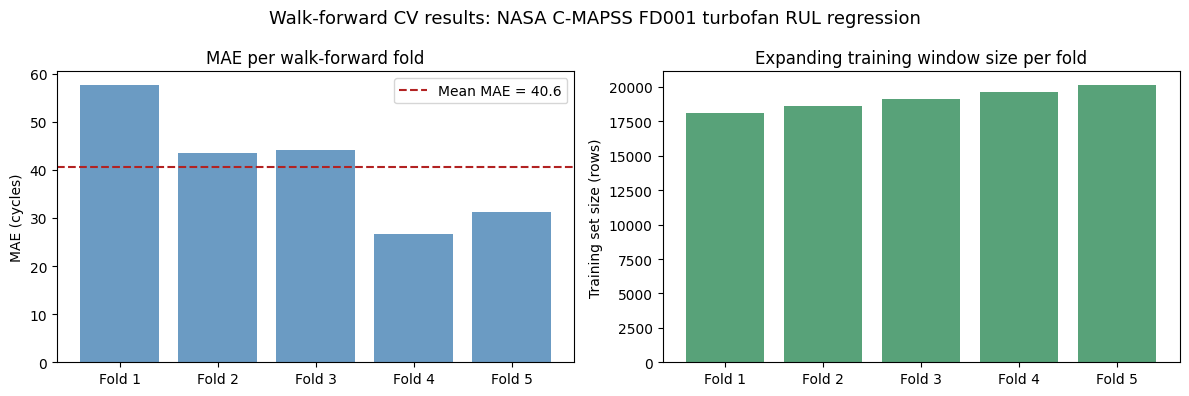

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Walk-forward CV results: NASA C-MAPSS FD001 turbofan RUL regression", fontsize=13)

fold_labels = [f"Fold {i + 1}" for i in range(len(fold_maes))]

ax1.bar(fold_labels, fold_maes, color="steelblue", alpha=0.8)
ax1.axhline(
    np.mean(fold_maes),
    color="firebrick",
    ls="--",
    lw=1.5,
    label=f"Mean MAE = {np.mean(fold_maes):.1f}",
)
ax1.set_ylabel("MAE (cycles)")
ax1.set_title("MAE per walk-forward fold")
ax1.legend()

ax2.bar(fold_labels, fold_train_sizes, color="seagreen", alpha=0.8)
ax2.set_ylabel("Training set size (rows)")
ax2.set_title("Expanding training window size per fold")

plt.tight_layout()
plt.show()

## Conclusion

Walk-forward CV is the evaluation protocol that actually matches predictive maintenance. It respects the one causal constraint that cannot be broken: a model deployed at time *T* can only have been trained on engine histories that existed before *T*.

The notebook makes a few specific choices to enforce that. The expanding window uses all pre-test data in each fold. `purge_horizon="3D"` removes cycles inside the lag window. `embargo="5D"` adds a further buffer against serial correlation in the sensor noise. And `diagnostics.assert_no_temporal_leakage` turns the guarantee into something you can audit rather than trust.

**Data attribution:** NASA C-MAPSS FD001 (Saxena et al., 2008, NASA Prognostics Center of Excellence). Data downloaded from https://github.com/hankroark/Turbofan-Engine-Degradation under NASA Open Government License.